In [1]:
# ==========================================
# FairXAI - Stage 2: Model Training
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
RANDOM_STATE = 42

# Project paths
project_path = Path(r"D:\TY_Sem1\MLOps\FairXAi")

processed_path = project_path / "data" / "processed"
artifacts_path = project_path / "artifacts"

print("Stage 2 environment initialized successfully.")
print("Project path:", project_path)
print("Processed data path:", processed_path)
print("Artifacts path:", artifacts_path)
print("Random state:", RANDOM_STATE)

Stage 2 environment initialized successfully.
Project path: D:\TY_Sem1\MLOps\FairXAi
Processed data path: D:\TY_Sem1\MLOps\FairXAi\data\processed
Artifacts path: D:\TY_Sem1\MLOps\FairXAi\artifacts
Random state: 42


In [2]:
# ==========================================
# Load Processed Train-Test Data
# ==========================================

target_column = "default payment next month"

train_processed_path = processed_path / "train_processed.csv"
test_processed_path = processed_path / "test_processed.csv"

# Load the processed datasets
train_processed = pd.read_csv(train_processed_path)
test_processed = pd.read_csv(test_processed_path)

print("Processed datasets loaded successfully!\n")

print("Training data:")
print("Shape:", train_processed.shape)

print("\nTesting data:")
print("Shape:", test_processed.shape)

# Separate features and target
X_train = train_processed.drop(columns=[target_column])
y_train = train_processed[target_column]

X_test = test_processed.drop(columns=[target_column])
y_test = test_processed[target_column]

print("\nFeature and target shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nTarget distribution:")
print("\nTraining:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Processed datasets loaded successfully!

Training data:
Shape: (24000, 34)

Testing data:
Shape: (6000, 34)

Feature and target shapes:
X_train: (24000, 33)
y_train: (24000,)
X_test : (6000, 33)
y_test : (6000,)

Target distribution:

Training:
default payment next month
0    18691
1     5309
Name: count, dtype: int64

Testing:
default payment next month
0    4673
1    1327
Name: count, dtype: int64


In [3]:
# ==========================================
# FairXAI Environment Verification
# ==========================================

import sys
import mlflow
import great_expectations as gx

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nMLflow version:")
print(mlflow.__version__)

print("\nGreat Expectations version:")
print(gx.__version__)

D:\TY_Sem1\MLOps\FairXAi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python executable:
D:\TY_Sem1\MLOps\FairXAi\.venv\Scripts\python.exe

Python version:
3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]

MLflow version:
3.16.0

Great Expectations version:
1.23.0


In [4]:
# ==========================================
# Great Expectations - Data Validation
# ==========================================

import great_expectations as gx

# Create a Great Expectations context
context = gx.get_context(mode="ephemeral")

# Create pandas data sources
train_source = context.data_sources.add_pandas("train_source")
test_source = context.data_sources.add_pandas("test_source")

# Create data assets
train_asset = train_source.add_dataframe_asset(name="train_processed")
test_asset = test_source.add_dataframe_asset(name="test_processed")

# Create batch definitions from our DataFrames
train_batch_definition = train_asset.add_batch_definition_whole_dataframe(
    "train_batch"
)

test_batch_definition = test_asset.add_batch_definition_whole_dataframe(
    "test_batch"
)

train_batch = train_batch_definition.get_batch(
    batch_parameters={"dataframe": train_processed}
)

test_batch = test_batch_definition.get_batch(
    batch_parameters={"dataframe": test_processed}
)

# ------------------------------------------
# Define expectations
# ------------------------------------------

# Training dataset
train_expectations = [
    gx.expectations.ExpectTableRowCountToEqual(value=24000),
    gx.expectations.ExpectTableColumnCountToEqual(value=34),
    gx.expectations.ExpectTableColumnsToMatchOrderedList(
        column_list=list(train_processed.columns)
    ),
    gx.expectations.ExpectColumnValuesToNotBeNull(
        column=target_column
    ),
    gx.expectations.ExpectColumnValuesToBeInSet(
        column=target_column,
        value_set=[0, 1]
    )
]

# Test dataset
test_expectations = [
    gx.expectations.ExpectTableRowCountToEqual(value=6000),
    gx.expectations.ExpectTableColumnCountToEqual(value=34),
    gx.expectations.ExpectTableColumnsToMatchOrderedList(
        column_list=list(test_processed.columns)
    ),
    gx.expectations.ExpectColumnValuesToNotBeNull(
        column=target_column
    ),
    gx.expectations.ExpectColumnValuesToBeInSet(
        column=target_column,
        value_set=[0, 1]
    )
]

# ------------------------------------------
# Validate training data
# ------------------------------------------

print("Validating training dataset...\n")

train_results = []

for expectation in train_expectations:
    result = train_batch.validate(expectation)
    train_results.append(result)

    print(
        f"{expectation.expectation_type}: "
        f"{'PASS' if result.success else 'FAIL'}"
    )

# ------------------------------------------
# Validate test data
# ------------------------------------------

print("\nValidating test dataset...\n")

test_results = []

for expectation in test_expectations:
    result = test_batch.validate(expectation)
    test_results.append(result)

    print(
        f"{expectation.expectation_type}: "
        f"{'PASS' if result.success else 'FAIL'}"
    )

# ------------------------------------------
# Final validation status
# ------------------------------------------

train_passed = all(result.success for result in train_results)
test_passed = all(result.success for result in test_results)

print("\n" + "=" * 50)
print("Great Expectations Validation Summary")
print("=" * 50)

print("Training data:", "PASSED" if train_passed else "FAILED")
print("Test data    :", "PASSED" if test_passed else "FAILED")

if train_passed and test_passed:
    print("\nData validation successful!")
    print("Safe to proceed with model training.")
else:
    print("\nData validation failed.")
    print("Do NOT proceed with model training.")

Validating training dataset...



Calculating Metrics: 100%|██████████| 1/1 [00:00<00:00, 243.20it/s]


expect_table_row_count_to_equal: PASS


Calculating Metrics: 100%|██████████| 3/3 [00:00<00:00, 749.25it/s]


expect_table_column_count_to_equal: PASS


...

expect_table_columns_to_match_ordered_list: PASS


Calculating Metrics: 100%|██████████| 8/8 [00:00<00:00, 888.72it/s] 


expect_column_values_to_not_be_null: PASS


Calculating Metrics: 100%|██████████| 10/10 [00:00<00:00, 1250.35it/s]

expect_column_values_to_be_in_set: PASS

Great Expectations Validation Summary
Training data: PASSED
Test data    : PASSED

Data validation successful!
Safe to proceed with model training.


In [5]:
# ==========================================
# MLflow Experiment Setup
# ==========================================

import mlflow

mlflow_db_path = project_path / "mlflow.db"

mlflow.set_tracking_uri(
    f"sqlite:///{mlflow_db_path.as_posix()}"
)

experiment_name = "FairXAI_Model_Training"

mlflow.set_experiment(experiment_name)

experiment = mlflow.get_experiment_by_name(experiment_name)

print("MLflow experiment ready!\n")

print("Experiment name :", experiment.name)
print("Experiment ID   :", experiment.experiment_id)
print("Tracking URI    :", mlflow.get_tracking_uri())
print("Database exists :", mlflow_db_path.exists())

MLflow experiment ready!

Experiment name : FairXAI_Model_Training
Experiment ID   : 1
Tracking URI    : sqlite:///D:/TY_Sem1/MLOps/FairXAi/mlflow.db
Database exists : True


In [6]:
# ==========================================
# Baseline Model - Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression

# Create baseline model
logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

# Start an MLflow run
with mlflow.start_run(run_name="Logistic_Regression_Baseline"):

    # Train the model
    logistic_model.fit(X_train, y_train)

    # Predictions
    y_pred = logistic_model.predict(X_test)
    y_prob = logistic_model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    logloss = log_loss(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    # Log model parameters
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("class_weight", "None")
    mlflow.log_param("max_iter", 1000)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.log_metric("log_loss", logloss)
    mlflow.log_metric("brier_score", brier)
    mlflow.log_metric("balanced_accuracy", balanced_acc)
    mlflow.log_metric("fpr", fpr)
    mlflow.log_metric("fnr", fnr)

    # Log the trained model
    mlflow.sklearn.log_model(
        logistic_model,
        name="logistic_regression_model"
    )

    # Display results
    print("Logistic Regression baseline trained successfully!\n")

    print("Evaluation Metrics")
    print("-" * 40)
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print(f"ROC-AUC           : {roc_auc:.4f}")
    print(f"PR-AUC            : {pr_auc:.4f}")
    print(f"Log Loss          : {logloss:.4f}")
    print(f"Brier Score       : {brier:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"FPR               : {fpr:.4f}")
    print(f"FNR               : {fnr:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

Logistic Regression baseline trained successfully!

Evaluation Metrics
----------------------------------------
Accuracy          : 0.8088
Precision         : 0.6923
Recall            : 0.2442
F1 Score          : 0.3610
ROC-AUC           : 0.7101
PR-AUC            : 0.4949
Log Loss          : 0.4704
Brier Score       : 0.1466
Balanced Accuracy : 0.6067
FPR               : 0.0308
FNR               : 0.7558

Confusion Matrix
[[4529  144]
 [1003  324]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [7]:
# ==========================================
# Baseline Model - KNN
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

# Create baseline KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Start MLflow run
with mlflow.start_run(run_name="KNN_Baseline"):

    # Train the model
    knn_model.fit(X_train, y_train)

    # Predictions
    y_pred = knn_model.predict(X_test)
    y_prob = knn_model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    logloss = log_loss(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    # Log parameters
    mlflow.log_param("model", "KNN")
    mlflow.log_param("n_neighbors", 5)
    mlflow.log_param("class_weight", "None")

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.log_metric("log_loss", logloss)
    mlflow.log_metric("brier_score", brier)
    mlflow.log_metric("balanced_accuracy", balanced_acc)
    mlflow.log_metric("fpr", fpr)
    mlflow.log_metric("fnr", fnr)

    # Log model
    mlflow.sklearn.log_model(
        knn_model,
        name="knn_model"
    )

    # Display results
    print("KNN baseline trained successfully!\n")

    print("Evaluation Metrics")
    print("-" * 40)
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print(f"ROC-AUC           : {roc_auc:.4f}")
    print(f"PR-AUC            : {pr_auc:.4f}")
    print(f"Log Loss          : {logloss:.4f}")
    print(f"Brier Score       : {brier:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"FPR               : {fpr:.4f}")
    print(f"FNR               : {fnr:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

KNN baseline trained successfully!

Evaluation Metrics
----------------------------------------
Accuracy          : 0.7952
Precision         : 0.5572
Recall            : 0.3595
F1 Score          : 0.4370
ROC-AUC           : 0.7046
PR-AUC            : 0.4185
Log Loss          : 2.2398
Brier Score       : 0.1616
Balanced Accuracy : 0.6392
FPR               : 0.0811
FNR               : 0.6405

Confusion Matrix
[[4294  379]
 [ 850  477]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4673
           1       0.56      0.36      0.44      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.64      0.66      6000
weighted avg       0.77      0.80      0.78      6000



In [8]:
# ==========================================
# KNN Hyperparameter Tuning
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Candidate K values
k_values = [3, 5, 7, 9, 11, 15, 21]

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

knn_cv_results = []

print("KNN Hyperparameter Tuning")
print("=" * 50)

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    # PR-AUC using training data only
    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    )

    mean_score = scores.mean()
    std_score = scores.std()

    knn_cv_results.append({
        "K": k,
        "Mean_PR_AUC": mean_score,
        "Std_PR_AUC": std_score
    })

    print(
        f"K = {k:2d} | "
        f"Mean PR-AUC = {mean_score:.4f} | "
        f"Std = {std_score:.4f}"
    )

# Convert results to DataFrame
knn_cv_results_df = pd.DataFrame(knn_cv_results)

# Select best K
best_k = knn_cv_results_df.loc[
    knn_cv_results_df["Mean_PR_AUC"].idxmax(),
    "K"
]

best_pr_auc = knn_cv_results_df.loc[
    knn_cv_results_df["Mean_PR_AUC"].idxmax(),
    "Mean_PR_AUC"
]

print("\n" + "=" * 50)
print("Best K:", best_k)
print(f"Best Mean CV PR-AUC: {best_pr_auc:.4f}")

KNN Hyperparameter Tuning
K =  3 | Mean PR-AUC = 0.3726 | Std = 0.0047
K =  5 | Mean PR-AUC = 0.4158 | Std = 0.0053
K =  7 | Mean PR-AUC = 0.4454 | Std = 0.0081
K =  9 | Mean PR-AUC = 0.4618 | Std = 0.0081
K = 11 | Mean PR-AUC = 0.4732 | Std = 0.0104
K = 15 | Mean PR-AUC = 0.4866 | Std = 0.0095
K = 21 | Mean PR-AUC = 0.4973 | Std = 0.0097

Best K: 21
Best Mean CV PR-AUC: 0.4973


In [9]:
# ==========================================
# Tuned KNN - K = 21
# ==========================================

best_knn_model = KNeighborsClassifier(
    n_neighbors=int(best_k)
)

with mlflow.start_run(run_name="KNN_Tuned"):

    # Train using the complete training set
    best_knn_model.fit(X_train, y_train)

    # Predictions
    y_pred = best_knn_model.predict(X_test)
    y_prob = best_knn_model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    logloss = log_loss(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    # Log parameters
    mlflow.log_param("model", "KNN")
    mlflow.log_param("n_neighbors", int(best_k))
    mlflow.log_param("selection_metric", "5-fold CV PR-AUC")

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.log_metric("log_loss", logloss)
    mlflow.log_metric("brier_score", brier)
    mlflow.log_metric("balanced_accuracy", balanced_acc)
    mlflow.log_metric("fpr", fpr)
    mlflow.log_metric("fnr", fnr)

    # Log model
    mlflow.sklearn.log_model(
        best_knn_model,
        name="knn_tuned_model"
    )

    # Display results
    print("Tuned KNN trained successfully!\n")

    print("Evaluation Metrics")
    print("-" * 40)
    print(f"K                 : {int(best_k)}")
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print(f"ROC-AUC           : {roc_auc:.4f}")
    print(f"PR-AUC            : {pr_auc:.4f}")
    print(f"Log Loss          : {logloss:.4f}")
    print(f"Brier Score       : {brier:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"FPR               : {fpr:.4f}")
    print(f"FNR               : {fnr:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

Tuned KNN trained successfully!

Evaluation Metrics
----------------------------------------
K                 : 21
Accuracy          : 0.8092
Precision         : 0.6250
Recall            : 0.3429
F1 Score          : 0.4428
ROC-AUC           : 0.7383
PR-AUC            : 0.4919
Log Loss          : 0.6575
Brier Score       : 0.1439
Balanced Accuracy : 0.6422
FPR               : 0.0584
FNR               : 0.6571

Confusion Matrix
[[4400  273]
 [ 872  455]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      4673
           1       0.62      0.34      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000



In [10]:
# ==========================================
# Baseline Model - Gaussian Naive Bayes
# ==========================================

from sklearn.naive_bayes import GaussianNB

# Create baseline model
nb_model = GaussianNB()

# Start MLflow run
with mlflow.start_run(run_name="Naive_Bayes_Baseline"):

    # Train the model
    nb_model.fit(X_train, y_train)

    # Predictions
    y_pred = nb_model.predict(X_test)
    y_prob = nb_model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    logloss = log_loss(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    # Log parameters
    mlflow.log_param("model", "Gaussian Naive Bayes")

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.log_metric("log_loss", logloss)
    mlflow.log_metric("brier_score", brier)
    mlflow.log_metric("balanced_accuracy", balanced_acc)
    mlflow.log_metric("fpr", fpr)
    mlflow.log_metric("fnr", fnr)

    # Log model
    mlflow.sklearn.log_model(
        nb_model,
        name="naive_bayes_model"
    )

    # Display results
    print("Naive Bayes baseline trained successfully!\n")

    print("Evaluation Metrics")
    print("-" * 40)
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print(f"ROC-AUC           : {roc_auc:.4f}")
    print(f"PR-AUC            : {pr_auc:.4f}")
    print(f"Log Loss          : {logloss:.4f}")
    print(f"Brier Score       : {brier:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"FPR               : {fpr:.4f}")
    print(f"FNR               : {fnr:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

Naive Bayes baseline trained successfully!

Evaluation Metrics
----------------------------------------
Accuracy          : 0.2913
Precision         : 0.2341
Recall            : 0.9706
F1 Score          : 0.3773
ROC-AUC           : 0.7240
PR-AUC            : 0.4610
Log Loss          : 5.6964
Brier Score       : 0.6989
Balanced Accuracy : 0.5345
FPR               : 0.9016
FNR               : 0.0294

Confusion Matrix
[[ 460 4213]
 [  39 1288]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.10      0.18      4673
           1       0.23      0.97      0.38      1327

    accuracy                           0.29      6000
   macro avg       0.58      0.53      0.28      6000
weighted avg       0.77      0.29      0.22      6000



In [11]:
# ==========================================
# Naive Bayes - Out-of-Fold Probabilities
# For Threshold Selection
# ==========================================

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.naive_bayes import GaussianNB

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Create Naive Bayes model
nb_threshold_model = GaussianNB()

# Generate out-of-fold probability predictions
# These predictions are produced only from training folds
nb_oof_prob = cross_val_predict(
    nb_threshold_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Out-of-fold probability generation completed!")
print("Number of training predictions:", len(nb_oof_prob))
print("Minimum probability:", nb_oof_prob.min())
print("Maximum probability:", nb_oof_prob.max())
print("Mean probability:", nb_oof_prob.mean())

Out-of-fold probability generation completed!
Number of training predictions: 24000
Minimum probability: 0.0
Maximum probability: 1.0
Mean probability: 0.9132376339636455


In [12]:
# ==========================================
# Naive Bayes - Threshold Analysis
# ==========================================

thresholds = np.arange(0.10, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into class predictions
    y_oof_pred = (nb_oof_prob >= threshold).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(y_train, y_oof_pred)
    precision = precision_score(y_train, y_oof_pred, zero_division=0)
    recall = recall_score(y_train, y_oof_pred, zero_division=0)
    f1 = f1_score(y_train, y_oof_pred, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_train, y_oof_pred)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_oof_pred
    ).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Balanced_Accuracy": balanced_acc,
        "FPR": fpr,
        "FNR": fnr
    })

threshold_results_df = pd.DataFrame(threshold_results)

print("Naive Bayes Threshold Analysis")
print("=" * 90)

print(
    threshold_results_df.to_string(
        index=False,
        formatters={
            "Threshold": "{:.2f}".format,
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1": "{:.4f}".format,
            "Balanced_Accuracy": "{:.4f}".format,
            "FPR": "{:.4f}".format,
            "FNR": "{:.4f}".format
        }
    )
)

# Find threshold with highest F1
best_f1_row = threshold_results_df.loc[
    threshold_results_df["F1"].idxmax()
]

print("\n" + "=" * 90)
print("Best threshold by F1")
print("=" * 90)

print(f"Threshold          : {best_f1_row['Threshold']:.2f}")
print(f"F1                 : {best_f1_row['F1']:.4f}")
print(f"Precision          : {best_f1_row['Precision']:.4f}")
print(f"Recall             : {best_f1_row['Recall']:.4f}")
print(f"Balanced Accuracy  : {best_f1_row['Balanced_Accuracy']:.4f}")
print(f"FPR                : {best_f1_row['FPR']:.4f}")
print(f"FNR                : {best_f1_row['FNR']:.4f}")


Naive Bayes Threshold Analysis
Threshold Accuracy Precision Recall     F1 Balanced_Accuracy    FPR    FNR
     0.10   0.2805    0.2312 0.9691 0.3734            0.5270 0.9151 0.0309
     0.15   0.2821    0.2316 0.9687 0.3738            0.5279 0.9130 0.0313
     0.20   0.2833    0.2318 0.9680 0.3740            0.5284 0.9112 0.0320
     0.25   0.2843    0.2320 0.9676 0.3743            0.5289 0.9098 0.0324
     0.30   0.2848    0.2320 0.9668 0.3742            0.5289 0.9090 0.0332
     0.35   0.2850    0.2319 0.9653 0.3740            0.5285 0.9082 0.0347
     0.40   0.2861    0.2321 0.9650 0.3742            0.5291 0.9067 0.0350
     0.45   0.2872    0.2324 0.9650 0.3746            0.5298 0.9054 0.0350
     0.50   0.2884    0.2326 0.9646 0.3749            0.5304 0.9037 0.0354
     0.55   0.2895    0.2329 0.9644 0.3752            0.5311 0.9023 0.0356
     0.60   0.2906    0.2331 0.9640 0.3755            0.5317 0.9006 0.0360
     0.65   0.2924    0.2335 0.9636 0.3760            0.5327 0.8983 0

In [13]:
# ==========================================
# Extended Naive Bayes Threshold Analysis
# ==========================================

extended_thresholds = [
    0.96,
    0.97,
    0.98,
    0.99,
    0.995,
    0.999
]

extended_results = []

for threshold in extended_thresholds:

    y_oof_pred = (nb_oof_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_train, y_oof_pred)
    precision = precision_score(
        y_train, y_oof_pred, zero_division=0
    )
    recall = recall_score(
        y_train, y_oof_pred, zero_division=0
    )
    f1 = f1_score(
        y_train, y_oof_pred, zero_division=0
    )
    balanced_acc = balanced_accuracy_score(
        y_train, y_oof_pred
    )

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_oof_pred
    ).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    extended_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Balanced_Accuracy": balanced_acc,
        "FPR": fpr,
        "FNR": fnr
    })

extended_threshold_results_df = pd.DataFrame(
    extended_results
)

print("Extended Naive Bayes Threshold Analysis")
print("=" * 90)

print(
    extended_threshold_results_df.to_string(
        index=False,
        formatters={
            "Threshold": "{:.3f}".format,
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1": "{:.4f}".format,
            "Balanced_Accuracy": "{:.4f}".format,
            "FPR": "{:.4f}".format,
            "FNR": "{:.4f}".format
        }
    )
)

Extended Naive Bayes Threshold Analysis
Threshold Accuracy Precision Recall     F1 Balanced_Accuracy    FPR    FNR
    0.960   0.3150    0.2378 0.9506 0.3804            0.5425 0.8656 0.0494
    0.970   0.3196    0.2387 0.9480 0.3813            0.5445 0.8589 0.0520
    0.980   0.3273    0.2404 0.9448 0.3833            0.5484 0.8481 0.0552
    0.990   0.3453    0.2438 0.9328 0.3866            0.5556 0.8216 0.0672
    0.995   0.3752    0.2502 0.9135 0.3928            0.5679 0.7776 0.0865
    0.999   0.5201    0.2902 0.8088 0.4271            0.6234 0.5619 0.1912


In [14]:
# ==========================================
# SVM Baseline
# ==========================================

from sklearn.svm import SVC

svm_baseline = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=RANDOM_STATE
)

svm_baseline.fit(X_train, y_train)

# Predictions
svm_pred = svm_baseline.predict(X_test)
svm_prob = svm_baseline.predict_proba(X_test)[:, 1]

# Classification metrics
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, zero_division=0)
svm_recall = recall_score(y_test, svm_pred, zero_division=0)
svm_f1 = f1_score(y_test, svm_pred, zero_division=0)
svm_balanced_accuracy = balanced_accuracy_score(y_test, svm_pred)

# Probability metrics
svm_roc_auc = roc_auc_score(y_test, svm_prob)
svm_pr_auc = average_precision_score(y_test, svm_prob)
svm_log_loss = log_loss(y_test, svm_prob)
svm_brier = brier_score_loss(y_test, svm_prob)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, svm_pred).ravel()

svm_fpr = fp / (fp + tn)
svm_fnr = fn / (fn + tp)

print("SVM Baseline")
print("=" * 60)
print(f"Kernel              : rbf")
print(f"C                   : 1.0")
print(f"Gamma               : scale")
print(f"Accuracy            : {svm_accuracy:.4f}")
print(f"Precision           : {svm_precision:.4f}")
print(f"Recall              : {svm_recall:.4f}")
print(f"F1 Score            : {svm_f1:.4f}")
print(f"ROC-AUC             : {svm_roc_auc:.4f}")
print(f"PR-AUC              : {svm_pr_auc:.4f}")
print(f"Log Loss            : {svm_log_loss:.4f}")
print(f"Brier Score         : {svm_brier:.4f}")
print(f"Balanced Accuracy   : {svm_balanced_accuracy:.4f}")
print(f"FPR                 : {svm_fpr:.4f}")
print(f"FNR                 : {svm_fnr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

SVM Baseline
Kernel              : rbf
C                   : 1.0
Gamma               : scale
Accuracy            : 0.8155
Precision           : 0.6613
Recall              : 0.3399
F1 Score            : 0.4490
ROC-AUC             : 0.7201
PR-AUC              : 0.5047
Log Loss            : 0.4587
Brier Score         : 0.1435
Balanced Accuracy   : 0.6452
FPR                 : 0.0494
FNR                 : 0.6601

Confusion Matrix:
[[4442  231]
 [ 876  451]]


In [15]:
# ==========================================
# Fast SVM Hyperparameter Tuning
# ==========================================

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC

cv_fast = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

svm = SVC(
    kernel="rbf",
    probability=False,
    random_state=RANDOM_STATE
)

param_grid = {
    "C": [0.1, 10],
    "gamma": ["scale", 0.1]
}

svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv_fast,
    n_jobs=-1,
    return_train_score=False
)

svm_grid.fit(X_train, y_train)

print("Fast SVM Hyperparameter Tuning")
print("=" * 60)
print(f"Best parameters: {svm_grid.best_params_}")
print(f"Best mean CV PR-AUC: {svm_grid.best_score_:.4f}")

print("\nAll Results:")
svm_cv_results = pd.DataFrame(svm_grid.cv_results_)

results_to_show = svm_cv_results[
    ["param_C", "param_gamma", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")

print(results_to_show.to_string(index=False))

Fast SVM Hyperparameter Tuning
Best parameters: {'C': 0.1, 'gamma': 'scale'}
Best mean CV PR-AUC: 0.5097

All Results:
 param_C param_gamma  mean_test_score  std_test_score  rank_test_score
     0.1       scale         0.509682        0.011580                1
     0.1         0.1         0.509111        0.008944                2
    10.0       scale         0.504063        0.006758                3
    10.0         0.1         0.481853        0.005832                4


In [16]:
# ==========================================
# Final Tuned SVM + MLflow Logging
# ==========================================

from sklearn.svm import SVC
import mlflow

# ------------------------------------------
# 1. Define tuned SVM
# ------------------------------------------

svm_tuned = SVC(
    kernel="rbf",
    C=0.1,
    gamma="scale",
    probability=True,
    random_state=RANDOM_STATE
)

# ------------------------------------------
# 2. Train on complete training set
# ------------------------------------------

svm_tuned.fit(X_train, y_train)

# ------------------------------------------
# 3. Predictions on untouched test set
# ------------------------------------------

svm_tuned_pred = svm_tuned.predict(X_test)
svm_tuned_prob = svm_tuned.predict_proba(X_test)[:, 1]

# ------------------------------------------
# 4. Calculate classification metrics
# ------------------------------------------

svm_tuned_accuracy = accuracy_score(y_test, svm_tuned_pred)
svm_tuned_precision = precision_score(y_test, svm_tuned_pred, zero_division=0)
svm_tuned_recall = recall_score(y_test, svm_tuned_pred, zero_division=0)
svm_tuned_f1 = f1_score(y_test, svm_tuned_pred, zero_division=0)

svm_tuned_balanced_accuracy = balanced_accuracy_score(
    y_test,
    svm_tuned_pred
)

# ------------------------------------------
# 5. Calculate probability metrics
# ------------------------------------------

svm_tuned_roc_auc = roc_auc_score(
    y_test,
    svm_tuned_prob
)

svm_tuned_pr_auc = average_precision_score(
    y_test,
    svm_tuned_prob
)

svm_tuned_log_loss = log_loss(
    y_test,
    svm_tuned_prob
)

svm_tuned_brier = brier_score_loss(
    y_test,
    svm_tuned_prob
)

# ------------------------------------------
# 6. Confusion matrix + FPR/FNR
# ------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    svm_tuned_pred
).ravel()

svm_tuned_fpr = fp / (fp + tn)
svm_tuned_fnr = fn / (fn + tp)

# ------------------------------------------
# 7. Display results
# ------------------------------------------

print("Final Tuned SVM")
print("=" * 60)

print("Kernel              : rbf")
print("C                   : 0.1")
print("Gamma               : scale")

print(f"Accuracy            : {svm_tuned_accuracy:.4f}")
print(f"Precision           : {svm_tuned_precision:.4f}")
print(f"Recall              : {svm_tuned_recall:.4f}")
print(f"F1 Score            : {svm_tuned_f1:.4f}")
print(f"ROC-AUC             : {svm_tuned_roc_auc:.4f}")
print(f"PR-AUC              : {svm_tuned_pr_auc:.4f}")
print(f"Log Loss            : {svm_tuned_log_loss:.4f}")
print(f"Brier Score         : {svm_tuned_brier:.4f}")
print(f"Balanced Accuracy   : {svm_tuned_balanced_accuracy:.4f}")
print(f"FPR                 : {svm_tuned_fpr:.4f}")
print(f"FNR                 : {svm_tuned_fnr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_tuned_pred))

# ------------------------------------------
# 8. MLflow logging
# ------------------------------------------

with mlflow.start_run(run_name="SVM_Tuned"):

    # Parameters
    mlflow.log_params({
        "model": "SVM",
        "kernel": "rbf",
        "C": 0.1,
        "gamma": "scale",
        "probability": True,
        "tuning_method": "GridSearchCV",
        "cv_folds": 3,
        "tuning_metric": "average_precision"
    })

    # Metrics
    mlflow.log_metrics({
        "accuracy": svm_tuned_accuracy,
        "precision": svm_tuned_precision,
        "recall": svm_tuned_recall,
        "f1": svm_tuned_f1,
        "roc_auc": svm_tuned_roc_auc,
        "pr_auc": svm_tuned_pr_auc,
        "log_loss": svm_tuned_log_loss,
        "brier_score": svm_tuned_brier,
        "balanced_accuracy": svm_tuned_balanced_accuracy,
        "fpr": svm_tuned_fpr,
        "fnr": svm_tuned_fnr
    })

print("\nMLflow logging completed!")
print("Run name: SVM_Tuned")

Final Tuned SVM
Kernel              : rbf
C                   : 0.1
Gamma               : scale
Accuracy            : 0.8118
Precision           : 0.6473
Recall              : 0.3278
F1 Score            : 0.4352
ROC-AUC             : 0.7136
PR-AUC              : 0.5045
Log Loss            : 0.4622
Brier Score         : 0.1450
Balanced Accuracy   : 0.6385
FPR                 : 0.0507
FNR                 : 0.6722

Confusion Matrix:
[[4436  237]
 [ 892  435]]

MLflow logging completed!
Run name: SVM_Tuned


In [17]:
# ==========================================
# Decision Tree Baseline + MLflow Logging
# ==========================================

from sklearn.tree import DecisionTreeClassifier

# ------------------------------------------
# 1. Define Decision Tree
# ------------------------------------------

dt_baseline = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE
)

# ------------------------------------------
# 2. Train on training data
# ------------------------------------------

dt_baseline.fit(X_train, y_train)

# ------------------------------------------
# 3. Predictions on untouched test set
# ------------------------------------------

dt_pred = dt_baseline.predict(X_test)
dt_prob = dt_baseline.predict_proba(X_test)[:, 1]

# ------------------------------------------
# 4. Classification metrics
# ------------------------------------------

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)

dt_balanced_accuracy = balanced_accuracy_score(
    y_test,
    dt_pred
)

# ------------------------------------------
# 5. Probability metrics
# ------------------------------------------

dt_roc_auc = roc_auc_score(y_test, dt_prob)
dt_pr_auc = average_precision_score(y_test, dt_prob)
dt_log_loss = log_loss(y_test, dt_prob)
dt_brier = brier_score_loss(y_test, dt_prob)

# ------------------------------------------
# 6. Confusion matrix + FPR/FNR
# ------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    dt_pred
).ravel()

dt_fpr = fp / (fp + tn)
dt_fnr = fn / (fn + tp)

# ------------------------------------------
# 7. Display results
# ------------------------------------------

print("Decision Tree Baseline")
print("=" * 60)

print("Criterion           : gini")
print("Max Depth           : None")
print("Min Samples Split   : 2")
print("Min Samples Leaf    : 1")

print(f"Accuracy            : {dt_accuracy:.4f}")
print(f"Precision           : {dt_precision:.4f}")
print(f"Recall              : {dt_recall:.4f}")
print(f"F1 Score            : {dt_f1:.4f}")
print(f"ROC-AUC             : {dt_roc_auc:.4f}")
print(f"PR-AUC              : {dt_pr_auc:.4f}")
print(f"Log Loss            : {dt_log_loss:.4f}")
print(f"Brier Score         : {dt_brier:.4f}")
print(f"Balanced Accuracy   : {dt_balanced_accuracy:.4f}")
print(f"FPR                 : {dt_fpr:.4f}")
print(f"FNR                 : {dt_fnr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

# ------------------------------------------
# 8. MLflow logging
# ------------------------------------------

with mlflow.start_run(run_name="Decision_Tree_Baseline"):

    mlflow.log_params({
        "model": "Decision Tree",
        "criterion": "gini",
        "max_depth": "None",
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "random_state": RANDOM_STATE,
        "class_weight": "None",
        "sampling": "Original"
    })

    mlflow.log_metrics({
        "accuracy": dt_accuracy,
        "precision": dt_precision,
        "recall": dt_recall,
        "f1": dt_f1,
        "roc_auc": dt_roc_auc,
        "pr_auc": dt_pr_auc,
        "log_loss": dt_log_loss,
        "brier_score": dt_brier,
        "balanced_accuracy": dt_balanced_accuracy,
        "fpr": dt_fpr,
        "fnr": dt_fnr
    })

print("\nMLflow logging completed!")
print("Run name: Decision_Tree_Baseline")

Decision Tree Baseline
Criterion           : gini
Max Depth           : None
Min Samples Split   : 2
Min Samples Leaf    : 1
Accuracy            : 0.7170
Precision           : 0.3702
Recall              : 0.3986
F1 Score            : 0.3839
ROC-AUC             : 0.6043
PR-AUC              : 0.2810
Log Loss            : 10.1712
Brier Score         : 0.2825
Balanced Accuracy   : 0.6030
FPR                 : 0.1926
FNR                 : 0.6014

Confusion Matrix:
[[3773  900]
 [ 798  529]]

MLflow logging completed!
Run name: Decision_Tree_Baseline


In [18]:
# ==========================================
# Decision Tree Hyperparameter Tuning
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

dt_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

dt = DecisionTreeClassifier(
    criterion="gini",
    random_state=RANDOM_STATE
)

dt_param_grid = {
    "max_depth": [3, 5, 7, 10, 15, 20],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    scoring="average_precision",
    cv=dt_cv,
    n_jobs=-1,
    return_train_score=False
)

dt_grid.fit(X_train, y_train)

print("Decision Tree Hyperparameter Tuning")
print("=" * 60)

print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best mean CV PR-AUC: {dt_grid.best_score_:.4f}")

print("\nTop Results:")

dt_cv_results = pd.DataFrame(dt_grid.cv_results_)

results_to_show = dt_cv_results[
    [
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

print(results_to_show.head(10).to_string(index=False))

Decision Tree Hyperparameter Tuning
Best parameters: {'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best mean CV PR-AUC: 0.5196

Top Results:
 param_max_depth  param_min_samples_split  param_min_samples_leaf  mean_test_score  std_test_score  rank_test_score
               7                       20                      10         0.519630        0.008914                1
               7                        2                      10         0.519630        0.008914                1
               7                       10                      10         0.519630        0.008914                1
               7                       20                       5         0.515154        0.010275                4
               5                        2                      10         0.514250        0.010670                5
               5                       20                      10         0.514250        0.010670                5
               5            

In [19]:
# ==========================================
# Final Tuned Decision Tree + MLflow
# ==========================================

from sklearn.tree import DecisionTreeClassifier

# ------------------------------------------
# 1. Define tuned Decision Tree
# ------------------------------------------

dt_tuned = DecisionTreeClassifier(
    criterion="gini",
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

# ------------------------------------------
# 2. Train on complete training set
# ------------------------------------------

dt_tuned.fit(X_train, y_train)

# ------------------------------------------
# 3. Predictions on untouched test set
# ------------------------------------------

dt_tuned_pred = dt_tuned.predict(X_test)
dt_tuned_prob = dt_tuned.predict_proba(X_test)[:, 1]

# ------------------------------------------
# 4. Classification metrics
# ------------------------------------------

dt_tuned_accuracy = accuracy_score(y_test, dt_tuned_pred)
dt_tuned_precision = precision_score(y_test, dt_tuned_pred, zero_division=0)
dt_tuned_recall = recall_score(y_test, dt_tuned_pred, zero_division=0)
dt_tuned_f1 = f1_score(y_test, dt_tuned_pred, zero_division=0)

dt_tuned_balanced_accuracy = balanced_accuracy_score(
    y_test,
    dt_tuned_pred
)

# ------------------------------------------
# 5. Probability metrics
# ------------------------------------------

dt_tuned_roc_auc = roc_auc_score(
    y_test,
    dt_tuned_prob
)

dt_tuned_pr_auc = average_precision_score(
    y_test,
    dt_tuned_prob
)

dt_tuned_log_loss = log_loss(
    y_test,
    dt_tuned_prob
)

dt_tuned_brier = brier_score_loss(
    y_test,
    dt_tuned_prob
)

# ------------------------------------------
# 6. Confusion matrix + FPR/FNR
# ------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    dt_tuned_pred
).ravel()

dt_tuned_fpr = fp / (fp + tn)
dt_tuned_fnr = fn / (fn + tp)

# ------------------------------------------
# 7. Display results
# ------------------------------------------

print("Final Tuned Decision Tree")
print("=" * 60)

print("Criterion           : gini")
print("Max Depth           : 7")
print("Min Samples Split   : 2")
print("Min Samples Leaf    : 10")

print(f"Accuracy            : {dt_tuned_accuracy:.4f}")
print(f"Precision           : {dt_tuned_precision:.4f}")
print(f"Recall              : {dt_tuned_recall:.4f}")
print(f"F1 Score            : {dt_tuned_f1:.4f}")
print(f"ROC-AUC             : {dt_tuned_roc_auc:.4f}")
print(f"PR-AUC              : {dt_tuned_pr_auc:.4f}")
print(f"Log Loss            : {dt_tuned_log_loss:.4f}")
print(f"Brier Score         : {dt_tuned_brier:.4f}")
print(f"Balanced Accuracy   : {dt_tuned_balanced_accuracy:.4f}")
print(f"FPR                 : {dt_tuned_fpr:.4f}")
print(f"FNR                 : {dt_tuned_fnr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_tuned_pred))

# ------------------------------------------
# 8. MLflow logging
# ------------------------------------------

with mlflow.start_run(run_name="Decision_Tree_Tuned"):

    mlflow.log_params({
        "model": "Decision Tree",
        "criterion": "gini",
        "max_depth": 7,
        "min_samples_split": 2,
        "min_samples_leaf": 10,
        "random_state": RANDOM_STATE,
        "class_weight": "None",
        "sampling": "Original",
        "tuning_method": "GridSearchCV",
        "cv_folds": 5,
        "tuning_metric": "average_precision"
    })

    mlflow.log_metrics({
        "accuracy": dt_tuned_accuracy,
        "precision": dt_tuned_precision,
        "recall": dt_tuned_recall,
        "f1": dt_tuned_f1,
        "roc_auc": dt_tuned_roc_auc,
        "pr_auc": dt_tuned_pr_auc,
        "log_loss": dt_tuned_log_loss,
        "brier_score": dt_tuned_brier,
        "balanced_accuracy": dt_tuned_balanced_accuracy,
        "fpr": dt_tuned_fpr,
        "fnr": dt_tuned_fnr
    })

print("\nMLflow logging completed!")
print("Run name: Decision_Tree_Tuned")

Final Tuned Decision Tree
Criterion           : gini
Max Depth           : 7
Min Samples Split   : 2
Min Samples Leaf    : 10
Accuracy            : 0.8182
Precision           : 0.6735
Recall              : 0.3451
F1 Score            : 0.4564
ROC-AUC             : 0.7488
PR-AUC              : 0.5078
Log Loss            : 0.5233
Brier Score         : 0.1398
Balanced Accuracy   : 0.6488
FPR                 : 0.0475
FNR                 : 0.6549

Confusion Matrix:
[[4451  222]
 [ 869  458]]

MLflow logging completed!
Run name: Decision_Tree_Tuned


In [20]:
# ==========================================
# Random Forest Baseline + MLflow Logging
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

# Predictions
rf_pred = rf_baseline.predict(X_test)
rf_prob = rf_baseline.predict_proba(X_test)[:, 1]

# Classification metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

rf_balanced_accuracy = balanced_accuracy_score(
    y_test,
    rf_pred
)

# Probability metrics
rf_roc_auc = roc_auc_score(y_test, rf_prob)
rf_pr_auc = average_precision_score(y_test, rf_prob)
rf_log_loss = log_loss(y_test, rf_prob)
rf_brier = brier_score_loss(y_test, rf_prob)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_test,
    rf_pred
).ravel()

rf_fpr = fp / (fp + tn)
rf_fnr = fn / (fn + tp)

# Display results
print("Random Forest Baseline")
print("=" * 60)

print("Estimators          : 200")
print("Criterion           : gini")
print("Max Depth           : None")
print("Min Samples Split   : 2")
print("Min Samples Leaf    : 1")

print(f"Accuracy            : {rf_accuracy:.4f}")
print(f"Precision           : {rf_precision:.4f}")
print(f"Recall              : {rf_recall:.4f}")
print(f"F1 Score            : {rf_f1:.4f}")
print(f"ROC-AUC             : {rf_roc_auc:.4f}")
print(f"PR-AUC              : {rf_pr_auc:.4f}")
print(f"Log Loss            : {rf_log_loss:.4f}")
print(f"Brier Score         : {rf_brier:.4f}")
print(f"Balanced Accuracy   : {rf_balanced_accuracy:.4f}")
print(f"FPR                 : {rf_fpr:.4f}")
print(f"FNR                 : {rf_fnr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

# MLflow logging
with mlflow.start_run(run_name="Random_Forest_Baseline"):

    mlflow.log_params({
        "model": "Random Forest",
        "n_estimators": 200,
        "criterion": "gini",
        "max_depth": "None",
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "class_weight": "None",
        "sampling": "Original"
    })

    mlflow.log_metrics({
        "accuracy": rf_accuracy,
        "precision": rf_precision,
        "recall": rf_recall,
        "f1": rf_f1,
        "roc_auc": rf_roc_auc,
        "pr_auc": rf_pr_auc,
        "log_loss": rf_log_loss,
        "brier_score": rf_brier,
        "balanced_accuracy": rf_balanced_accuracy,
        "fpr": rf_fpr,
        "fnr": rf_fnr
    })

print("\nMLflow logging completed!")
print("Run name: Random_Forest_Baseline")

Random Forest Baseline
Estimators          : 200
Criterion           : gini
Max Depth           : None
Min Samples Split   : 2
Min Samples Leaf    : 1
Accuracy            : 0.8135
Precision           : 0.6354
Recall              : 0.3677
F1 Score            : 0.4659
ROC-AUC             : 0.7582
PR-AUC              : 0.5355
Log Loss            : 0.4441
Brier Score         : 0.1392
Balanced Accuracy   : 0.6539
FPR                 : 0.0599
FNR                 : 0.6323

Confusion Matrix:
[[4393  280]
 [ 839  488]]

MLflow logging completed!
Run name: Random_Forest_Baseline


In [21]:
# ==========================================
# Random Forest Hyperparameter Tuning
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

rf_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_param_grid = {
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="average_precision",
    cv=rf_cv,
    n_jobs=-1,
    return_train_score=False
)

rf_grid.fit(X_train, y_train)

print("Random Forest Hyperparameter Tuning")
print("=" * 60)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best mean CV PR-AUC: {rf_grid.best_score_:.4f}")

print("\nTop Results:")

rf_cv_results = pd.DataFrame(rf_grid.cv_results_)

results_to_show = rf_cv_results[
    [
        "param_max_depth",
        "param_min_samples_leaf",
        "param_max_features",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

print(results_to_show.head(10).to_string(index=False))

Random Forest Hyperparameter Tuning
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1}
Best mean CV PR-AUC: 0.5567

Top Results:
param_max_depth  param_min_samples_leaf param_max_features  mean_test_score  std_test_score  rank_test_score
             10                       1               sqrt         0.556716        0.005696                1
             10                       1               log2         0.556716        0.005696                1
             10                       5               log2         0.556396        0.006975                3
             10                       5               sqrt         0.556396        0.006975                3
             10                      10               log2         0.556200        0.008740                5
             10                      10               sqrt         0.556200        0.008740                5
             20                      10               sqrt         0.554831  

In [22]:
# ==========================================
# Final Tuned Random Forest + MLflow
# ==========================================

from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------
# 1. Define tuned Random Forest
# ------------------------------------------

rf_tuned = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# ------------------------------------------
# 2. Train on complete training set
# ------------------------------------------

rf_tuned.fit(X_train, y_train)

# ------------------------------------------
# 3. Predictions on untouched test set
# ------------------------------------------

rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_prob = rf_tuned.predict_proba(X_test)[:, 1]

# ------------------------------------------
# 4. Classification metrics
# ------------------------------------------

rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)
rf_tuned_precision = precision_score(y_test, rf_tuned_pred, zero_division=0)
rf_tuned_recall = recall_score(y_test, rf_tuned_pred, zero_division=0)
rf_tuned_f1 = f1_score(y_test, rf_tuned_pred, zero_division=0)

rf_tuned_balanced_accuracy = balanced_accuracy_score(
    y_test,
    rf_tuned_pred
)

# ------------------------------------------
# 5. Probability metrics
# ------------------------------------------

rf_tuned_roc_auc = roc_auc_score(y_test, rf_tuned_prob)
rf_tuned_pr_auc = average_precision_score(y_test, rf_tuned_prob)
rf_tuned_log_loss = log_loss(y_test, rf_tuned_prob)
rf_tuned_brier = brier_score_loss(y_test, rf_tuned_prob)

# ------------------------------------------
# 6. Confusion matrix + FPR/FNR
# ------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    rf_tuned_pred
).ravel()

rf_tuned_fpr = fp / (fp + tn)
rf_tuned_fnr = fn / (fn + tp)

# ------------------------------------------
# 7. Display results
# ------------------------------------------

print("Final Tuned Random Forest")
print("=" * 60)

print("Estimators          : 200")
print("Criterion           : gini")
print("Max Depth           : 10")
print("Min Samples Split   : 2")
print("Min Samples Leaf    : 1")
print("Max Features        : sqrt")

print(f"Accuracy            : {rf_tuned_accuracy:.4f}")
print(f"Precision           : {rf_tuned_precision:.4f}")
print(f"Recall              : {rf_tuned_recall:.4f}")
print(f"F1 Score            : {rf_tuned_f1:.4f}")
print(f"ROC-AUC             : {rf_tuned_roc_auc:.4f}")
print(f"PR-AUC              : {rf_tuned_pr_auc:.4f}")
print(f"Log Loss            : {rf_tuned_log_loss:.4f}")
print(f"Brier Score         : {rf_tuned_brier:.4f}")
print(f"Balanced Accuracy   : {rf_tuned_balanced_accuracy:.4f}")
print(f"FPR                 : {rf_tuned_fpr:.4f}")
print(f"FNR                 : {rf_tuned_fnr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_tuned_pred))

# ------------------------------------------
# 8. MLflow logging
# ------------------------------------------

with mlflow.start_run(run_name="Random_Forest_Tuned"):

    mlflow.log_params({
        "model": "Random Forest",
        "n_estimators": 200,
        "criterion": "gini",
        "max_depth": 10,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "random_state": RANDOM_STATE,
        "class_weight": "None",
        "sampling": "Original",
        "tuning_method": "GridSearchCV",
        "cv_folds": 3,
        "tuning_metric": "average_precision"
    })

    mlflow.log_metrics({
        "accuracy": rf_tuned_accuracy,
        "precision": rf_tuned_precision,
        "recall": rf_tuned_recall,
        "f1": rf_tuned_f1,
        "roc_auc": rf_tuned_roc_auc,
        "pr_auc": rf_tuned_pr_auc,
        "log_loss": rf_tuned_log_loss,
        "brier_score": rf_tuned_brier,
        "balanced_accuracy": rf_tuned_balanced_accuracy,
        "fpr": rf_tuned_fpr,
        "fnr": rf_tuned_fnr
    })

print("\nMLflow logging completed!")
print("Run name: Random_Forest_Tuned")

Final Tuned Random Forest
Estimators          : 200
Criterion           : gini
Max Depth           : 10
Min Samples Split   : 2
Min Samples Leaf    : 1
Max Features        : sqrt
Accuracy            : 0.8158
Precision           : 0.6604
Recall              : 0.3444
F1 Score            : 0.4527
ROC-AUC             : 0.7736
PR-AUC              : 0.5526
Log Loss            : 0.4330
Brier Score         : 0.1360
Balanced Accuracy   : 0.6470
FPR                 : 0.0503
FNR                 : 0.6556

Confusion Matrix:
[[4438  235]
 [ 870  457]]

MLflow logging completed!
Run name: Random_Forest_Tuned


In [24]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [25]:
# ==========================================
# XGBoost Baseline + MLflow Logging
# ==========================================

from xgboost import XGBClassifier

# ------------------------------------------
# 1. Define XGBoost baseline
# ------------------------------------------

xgb_baseline = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# ------------------------------------------
# 2. Train on training data
# ------------------------------------------

xgb_baseline.fit(X_train, y_train)

# ------------------------------------------
# 3. Predictions on untouched test set
# ------------------------------------------

xgb_pred = xgb_baseline.predict(X_test)
xgb_prob = xgb_baseline.predict_proba(X_test)[:, 1]

# ------------------------------------------
# 4. Classification metrics
# ------------------------------------------

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)

xgb_balanced_accuracy = balanced_accuracy_score(
    y_test,
    xgb_pred
)

# ------------------------------------------
# 5. Probability metrics
# ------------------------------------------

xgb_roc_auc = roc_auc_score(y_test, xgb_prob)
xgb_pr_auc = average_precision_score(y_test, xgb_prob)
xgb_log_loss = log_loss(y_test, xgb_prob)
xgb_brier = brier_score_loss(y_test, xgb_prob)

# ------------------------------------------
# 6. Confusion matrix + FPR/FNR
# ------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    xgb_pred
).ravel()

xgb_fpr = fp / (fp + tn)
xgb_fnr = fn / (fn + tp)

# ------------------------------------------
# 7. Display results
# ------------------------------------------

print("XGBoost Baseline")
print("=" * 60)

print("Estimators          : 200")
print("Max Depth           : 6")
print("Learning Rate       : 0.1")
print("Subsample           : 1.0")
print("Column Sample       : 1.0")

print(f"Accuracy            : {xgb_accuracy:.4f}")
print(f"Precision           : {xgb_precision:.4f}")
print(f"Recall              : {xgb_recall:.4f}")
print(f"F1 Score            : {xgb_f1:.4f}")
print(f"ROC-AUC             : {xgb_roc_auc:.4f}")
print(f"PR-AUC              : {xgb_pr_auc:.4f}")
print(f"Log Loss            : {xgb_log_loss:.4f}")
print(f"Brier Score         : {xgb_brier:.4f}")
print(f"Balanced Accuracy   : {xgb_balanced_accuracy:.4f}")
print(f"FPR                 : {xgb_fpr:.4f}")
print(f"FNR                 : {xgb_fnr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

# ------------------------------------------
# 8. MLflow logging
# ------------------------------------------

with mlflow.start_run(run_name="XGBoost_Baseline"):

    mlflow.log_params({
        "model": "XGBoost",
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 1.0,
        "colsample_bytree": 1.0,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
        "sampling": "Original"
    })

    mlflow.log_metrics({
        "accuracy": xgb_accuracy,
        "precision": xgb_precision,
        "recall": xgb_recall,
        "f1": xgb_f1,
        "roc_auc": xgb_roc_auc,
        "pr_auc": xgb_pr_auc,
        "log_loss": xgb_log_loss,
        "brier_score": xgb_brier,
        "balanced_accuracy": xgb_balanced_accuracy,
        "fpr": xgb_fpr,
        "fnr": xgb_fnr
    })

print("\nMLflow logging completed!")
print("Run name: XGBoost_Baseline")

XGBoost Baseline
Estimators          : 200
Max Depth           : 6
Learning Rate       : 0.1
Subsample           : 1.0
Column Sample       : 1.0
Accuracy            : 0.8143
Precision           : 0.6399
Recall              : 0.3670
F1 Score            : 0.4665
ROC-AUC             : 0.7712
PR-AUC              : 0.5400
Log Loss            : 0.4398
Brier Score         : 0.1379
Balanced Accuracy   : 0.6542
FPR                 : 0.0586
FNR                 : 0.6330

Confusion Matrix:
[[4399  274]
 [ 840  487]]

MLflow logging completed!
Run name: XGBoost_Baseline


In [26]:
# ==========================================
# Stage 2: Model Comparison
# ==========================================

model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.8088,
        "Precision": 0.6923,
        "Recall": 0.2442,
        "F1": 0.3610,
        "ROC-AUC": 0.7101,
        "PR-AUC": 0.4949,
        "Log Loss": 0.4704,
        "Brier": 0.1466,
        "Balanced Accuracy": 0.6067,
        "FPR": 0.0308,
        "FNR": 0.7558
    },
    {
        "Model": "KNN",
        "Accuracy": 0.8092,
        "Precision": 0.6250,
        "Recall": 0.3429,
        "F1": 0.4428,
        "ROC-AUC": 0.7383,
        "PR-AUC": 0.4919,
        "Log Loss": 0.6575,
        "Brier": 0.1439,
        "Balanced Accuracy": 0.6422,
        "FPR": 0.0584,
        "FNR": 0.6571
    },
    {
        "Model": "Naive Bayes",
        "Accuracy": 0.2913,
        "Precision": 0.2341,
        "Recall": 0.9706,
        "F1": 0.3773,
        "ROC-AUC": 0.7240,
        "PR-AUC": 0.4610,
        "Log Loss": 5.6964,
        "Brier": 0.6989,
        "Balanced Accuracy": 0.5345,
        "FPR": 0.9016,
        "FNR": 0.0294
    },
    {
        "Model": "SVM",
        "Accuracy": 0.8155,
        "Precision": 0.6613,
        "Recall": 0.3399,
        "F1": 0.4490,
        "ROC-AUC": 0.7201,
        "PR-AUC": 0.5047,
        "Log Loss": 0.4587,
        "Brier": 0.1435,
        "Balanced Accuracy": 0.6452,
        "FPR": 0.0494,
        "FNR": 0.6601
    },
    {
        "Model": "Decision Tree",
        "Accuracy": 0.8182,
        "Precision": 0.6735,
        "Recall": 0.3451,
        "F1": 0.4564,
        "ROC-AUC": 0.7488,
        "PR-AUC": 0.5078,
        "Log Loss": 0.5233,
        "Brier": 0.1398,
        "Balanced Accuracy": 0.6488,
        "FPR": 0.0475,
        "FNR": 0.6549
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.8158,
        "Precision": 0.6604,
        "Recall": 0.3444,
        "F1": 0.4527,
        "ROC-AUC": 0.7736,
        "PR-AUC": 0.5526,
        "Log Loss": 0.4330,
        "Brier": 0.1360,
        "Balanced Accuracy": 0.6470,
        "FPR": 0.0503,
        "FNR": 0.6556
    },
    {
        "Model": "XGBoost",
        "Accuracy": 0.8143,
        "Precision": 0.6399,
        "Recall": 0.3670,
        "F1": 0.4665,
        "ROC-AUC": 0.7712,
        "PR-AUC": 0.5400,
        "Log Loss": 0.4398,
        "Brier": 0.1379,
        "Balanced Accuracy": 0.6542,
        "FPR": 0.0586,
        "FNR": 0.6330
    }
])

model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss,Brier,Balanced Accuracy,FPR,FNR
0,Logistic Regression,0.8088,0.6923,0.2442,0.3610,0.7101,0.4949,0.4704,0.1466,0.6067,0.0308,0.7558
1,KNN,0.8092,0.6250,0.3429,0.4428,0.7383,0.4919,0.6575,0.1439,0.6422,0.0584,0.6571
2,Naive Bayes,0.2913,0.2341,0.9706,0.3773,0.7240,0.4610,5.6964,0.6989,0.5345,0.9016,0.0294
3,SVM,0.8155,0.6613,0.3399,0.4490,0.7201,0.5047,0.4587,0.1435,0.6452,0.0494,0.6601
4,Decision Tree,0.8182,0.6735,0.3451,0.4564,0.7488,0.5078,0.5233,0.1398,0.6488,0.0475,0.6549
5,Random Forest,0.8158,0.6604,0.3444,0.4527,0.7736,0.5526,0.4330,0.1360,0.6470,0.0503,0.6556
6,XGBoost,0.8143,0.6399,0.3670,0.4665,0.7712,0.5400,0.4398,0.1379,0.6542,0.0586,0.6330


In [27]:
# Round metrics for clean presentation

comparison_table = model_results.copy()

metric_columns = comparison_table.columns[1:]

comparison_table[metric_columns] = comparison_table[metric_columns].round(4)

comparison_table

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss,Brier,Balanced Accuracy,FPR,FNR
0,Logistic Regression,0.8088,0.6923,0.2442,0.3610,0.7101,0.4949,0.4704,0.1466,0.6067,0.0308,0.7558
1,KNN,0.8092,0.6250,0.3429,0.4428,0.7383,0.4919,0.6575,0.1439,0.6422,0.0584,0.6571
2,Naive Bayes,0.2913,0.2341,0.9706,0.3773,0.7240,0.4610,5.6964,0.6989,0.5345,0.9016,0.0294
3,SVM,0.8155,0.6613,0.3399,0.4490,0.7201,0.5047,0.4587,0.1435,0.6452,0.0494,0.6601
4,Decision Tree,0.8182,0.6735,0.3451,0.4564,0.7488,0.5078,0.5233,0.1398,0.6488,0.0475,0.6549
5,Random Forest,0.8158,0.6604,0.3444,0.4527,0.7736,0.5526,0.4330,0.1360,0.6470,0.0503,0.6556
6,XGBoost,0.8143,0.6399,0.3670,0.4665,0.7712,0.5400,0.4398,0.1379,0.6542,0.0586,0.6330


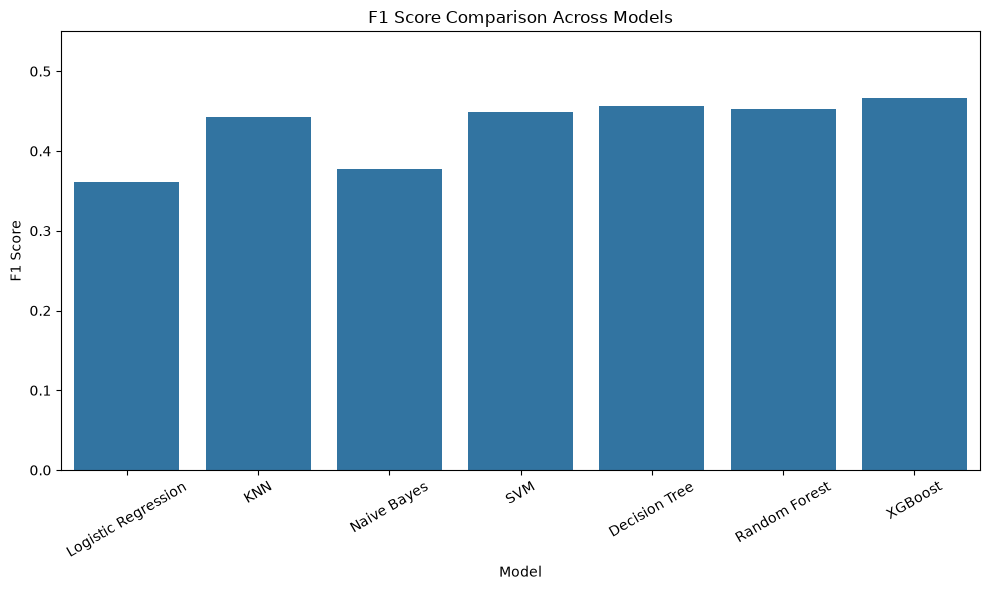

In [28]:
# ==========================================
# Model Comparison: F1 Score
# ==========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_table,
    x="Model",
    y="F1"
)

plt.title("F1 Score Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.ylim(0, 0.55)
plt.tight_layout()
plt.show()

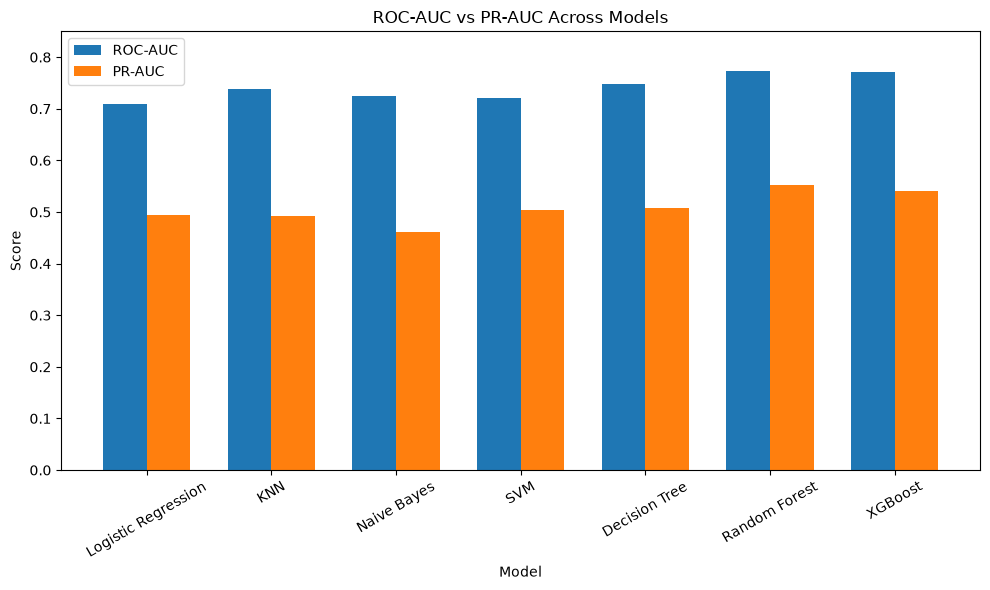

In [29]:
# ==========================================
# Model Comparison: ROC-AUC vs PR-AUC
# ==========================================

plt.figure(figsize=(10, 6))

x = np.arange(len(comparison_table))
width = 0.35

plt.bar(
    x - width / 2,
    comparison_table["ROC-AUC"],
    width,
    label="ROC-AUC"
)

plt.bar(
    x + width / 2,
    comparison_table["PR-AUC"],
    width,
    label="PR-AUC"
)

plt.title("ROC-AUC vs PR-AUC Across Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(x, comparison_table["Model"], rotation=30)
plt.ylim(0, 0.85)
plt.legend()
plt.tight_layout()
plt.show()

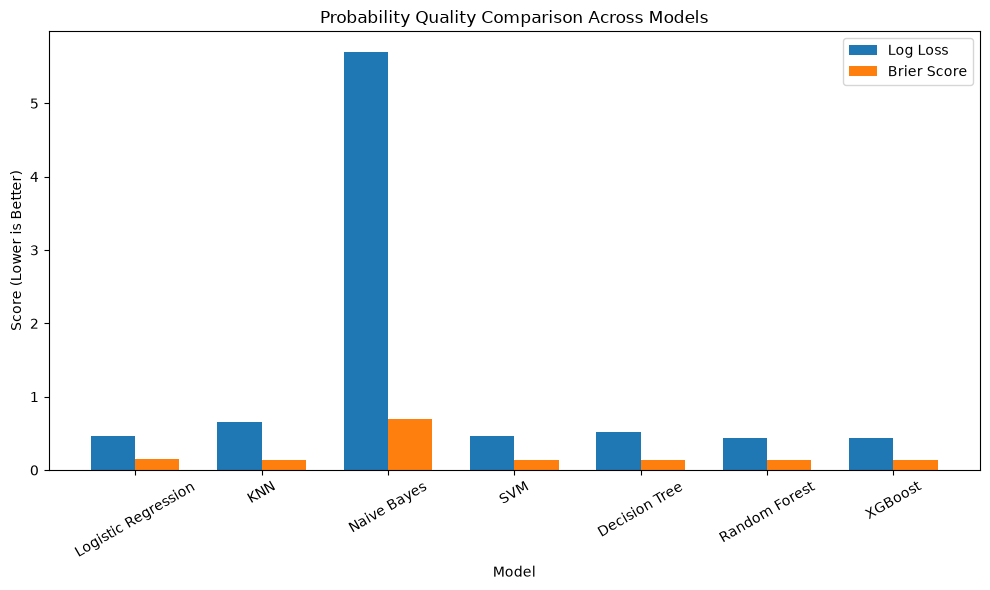

In [30]:
# ==========================================
# Model Comparison: Log Loss vs Brier Score
# ==========================================

plt.figure(figsize=(10, 6))

x = np.arange(len(comparison_table))
width = 0.35

plt.bar(
    x - width / 2,
    comparison_table["Log Loss"],
    width,
    label="Log Loss"
)

plt.bar(
    x + width / 2,
    comparison_table["Brier"],
    width,
    label="Brier Score"
)

plt.title("Probability Quality Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Score (Lower is Better)")
plt.xticks(x, comparison_table["Model"], rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Stage 2 Findings — Model Comparison

The seven selected machine learning models were evaluated on the same untouched test set using classification, ranking, and probability-quality metrics.

### Key observations

- The models show relatively similar F1 scores, with XGBoost achieving the highest F1 score (0.4665) among the evaluated configurations.
- Random Forest achieved the highest ROC-AUC (0.7736) and PR-AUC (0.5526), indicating strong ranking performance for identifying default cases.
- XGBoost also showed strong ranking performance, with ROC-AUC of 0.7712 and PR-AUC of 0.5400.
- Decision Tree achieved the highest accuracy (0.8182) among the evaluated configurations, but accuracy alone is not sufficient for assessing performance on this imbalanced dataset.
- Naive Bayes produced very high recall (0.9706), but this was accompanied by a very high false positive rate (0.9016) and substantially worse Log Loss and Brier Score. This indicates that its predictions were poorly suited to the current data and operating threshold.
- Logistic Regression produced the lowest false positive rate (0.0308), but also had relatively low recall (0.2442), showing a trade-off between avoiding false positives and detecting default cases.
- The results demonstrate that no single metric fully describes model performance. Therefore, accuracy, F1, ROC-AUC, PR-AUC, recall, false positive/negative rates, Log Loss, and Brier Score should be considered together.

### Stage 2 Conclusion

The baseline model comparison establishes the predictive behavior of the seven candidate algorithms on the original class distribution. Ensemble models, particularly Random Forest and XGBoost, demonstrated strong ranking performance, while other models exhibited different trade-offs between precision, recall, false positives, and probability quality.

The results from this stage will be used as the baseline for the next experiment, where the effect of class imbalance handling will be evaluated using the original class distribution, class weighting, and SMOTE.